# Contextualização

![](https://media-exp1.licdn.com/dms/image/C4E12AQGbAM-_eriLMw/article-cover_image-shrink_720_1280/0/1632916005843?e=1669248000&v=beta&t=Jrz7HA1m-Qbhm08T89CaeaESJnsodVxsetVxJHVsVKM)

[Fonte da imagem](https://www.linkedin.com/pulse/supervised-vs-unsupervised-learning-whats-difference-smriti-saini/)

**Aprendizado não-supervisionado (unsupervised learning)**

No aprendizado não supervisionado, do qual **clustering** faz parte, **não há variável resposta**, e entre seus objetivos estão o tratamento, exploração e diagnóstico dos dados (exemplo: encontrar padrões).

**Exemplos:**
- **Clustering:** identificar e agrupar observações similares.
- **Dimensionality reduction:** reduzir a quantidade de dimensões (variáveis).

**Quantos algoritmos não-supervisionados temos?**

- Clustering: [https://scikit-learn.org/stable/modules/clustering.html](https://scikit-learn.org/stable/modules/clustering.html)
- Dimentionality reduction: [https://scikit-learn.org/stable/modules/classes.html#module-sklearn.decomposition](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.decomposition)

**Classifique como tarefa supervisionada ou não-supervisionada:**

1. Segmentação de clientes para entendermos melhor diferentes perfis: ________
2. Classificação de clientes em churn e não-churn: ________
3. Agrupamento de produtos similares entre si: ________
4. Redução da dimensionalidade dos dados: ________
5. Previsão da probabilidade de um cliente contratar o serviço: ________

<details>
  <summary><b>Respostas</b></summary>
  <ol type="1">
  <li><b>unsupervised learning</b></li>
  <li>supervised learning</li>
  <li><b>unsupervised learning</b></li>
  <li><b>unsupervised learning</b></li>
  <li>supervised learning</li>
  </ol>
</details>

# Setup

In [2]:
# %%capture
# %pip install kmodes
# !pip install yellowbrick
# !pip install ipywidgets

In [3]:
# Data wrangling
import numpy as np
import pandas as pd

# Dataviz
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer, InterclusterDistance, kelbow_visualizer, silhouette_visualizer

## -- Machine learning -- ##
from sklearn import datasets
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans, DBSCAN, MeanShift
from sklearn.cluster import k_means, dbscan, mean_shift, estimate_bandwidth
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

from kmodes.kmodes import KModes            # clustering categorical data
from kmodes.kprototypes import KPrototypes  # clustering mixed data

# Didatic purposes
import string
from ipywidgets import interact

In [4]:
import matplotlib.pyplot as plt


In [5]:
# https://matplotlib.org/stable/tutorials/introductory/customizing.html
sns.set_theme(
    context='talk',
    style='ticks',
    font_scale=.8,
    palette='tab10',
    rc={
        'figure.figsize': (12,8),
        'axes.grid': True,
        'grid.alpha': .2,
        'axes.titlesize': 'x-large',
        'axes.titleweight': 'bold',
        'axes.titlepad': 20,
    }
)

scatter_kwargs = dict(palette='viridis', alpha=0.8, linewidth=0)

# K-means

Apps de simulação:
- [Versão em português (streamlit)](https://cmcouto-silva-kmeans-app-pt-streamlit-app-tyl62y.streamlitapp.com/)
- [Versão em português (dash)](https://kmeans-animation-pt.herokuapp.com/)
- [Versão em inglês](https://cmcouto-silva-kmeans-app-en-streamlit-app-v886a2.streamlitapp.com/)

**Requerimentos:**
- Dados numéricos contínuos
- Dados na mesma escala
- Pré-determinação do número de grupos (k)

**Vantagens:**
- Simples
- Eficiente
- Escalável para uma grande quantidade de dados

**Desvantagens:**
- Sensível a outliers
- Pré-determinação do número de grupos (k)
- Não adequado para dados categóricos (mesmo com one-hot encoding)
- Agrupa apenas pontos próximos entre si

Por quê não utilizar dummies no algoritmo? Vide:
- [https://www.ibm.com/support/pages/clustering-binary-data-k-means-should-be-avoided](https://www.ibm.com/support/pages/clustering-binary-data-k-means-should-be-avoided)
- Livro: Practical Statistics for Data Scientists (Peter Bruce et al., 2020)
- Statistical foruns

## Simulated Data

In [6]:
# Simulate clusters
X,y = datasets.make_blobs(n_samples=int(5E3), n_features=2, centers=4, cluster_std=.8, random_state=42)
df = pd.DataFrame(X, columns=list(string.ascii_uppercase[:X.shape[1]]))
df.head()

,A,B
0,3.851236,1.745846
1,-7.873424,-7.780579
2,3.961772,1.451499
3,-7.762175,-6.223667
4,-9.208354,7.633667


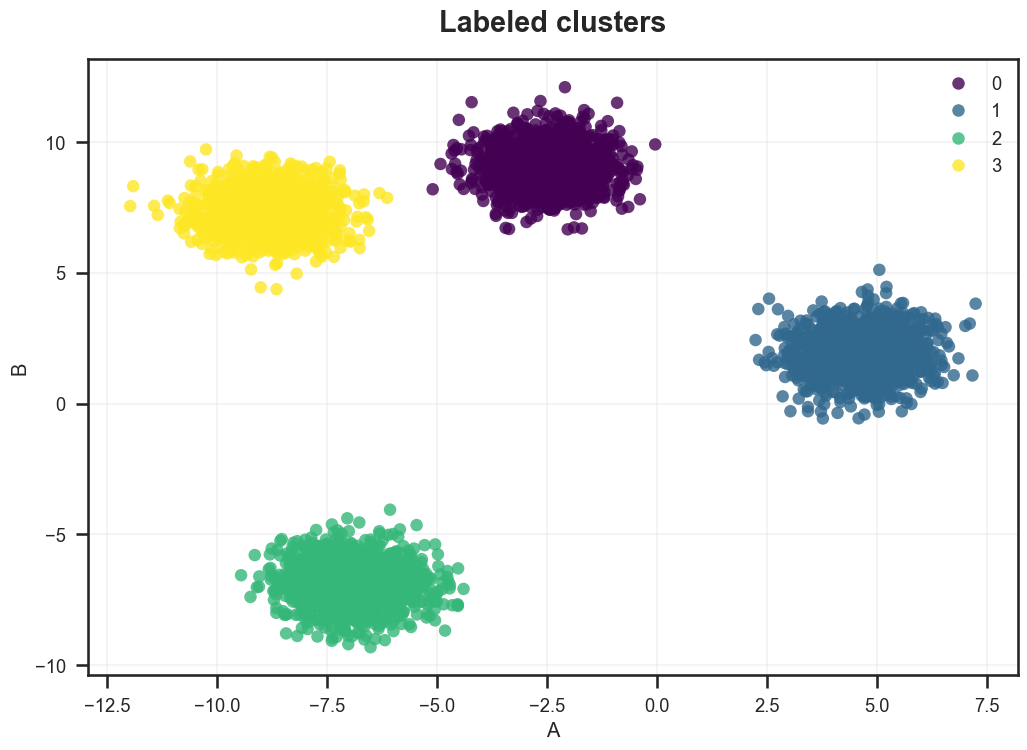

In [7]:
# Visualize simulated clusters
sns.scatterplot(data=df, x='A', y='B', hue=y, **scatter_kwargs)
plt.title('Labeled clusters')
plt.show()

## Distinct APIs for K-means

No sklearn, podemos utilizar algoritmos de clusterização através classes ou funções (vide [este link](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.cluster)).

In [8]:
# Usando função
k_means(X, n_clusters=4, random_state=42)


(array([[ 4.62826191,  1.94726375],
        [-2.50138934,  9.05833956],
        [-6.89143046, -6.91208453],
        [-8.83866084,  7.33763741]]),
 array([0, 2, 0, ..., 0, 1, 0], shape=(5000,), dtype=int32),
 6438.463928042345)

In [9]:
centroids, labels, intertia = k_means(X, n_clusters=4)

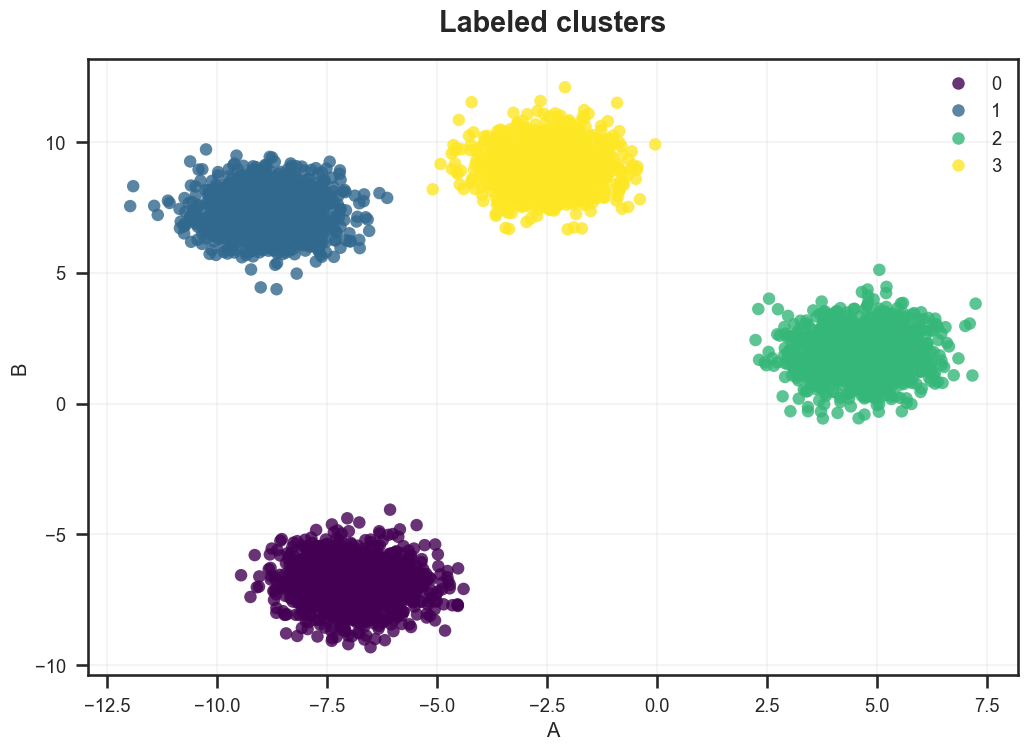

In [10]:
sns.scatterplot(data=df, x='A', y='B', hue=labels, **scatter_kwargs)
plt.title('Labeled clusters')
plt.show()

## Distinct APIs for K-means

No sklearn, podemos utilizar algoritmos de clusterização através classes ou funções (vide [este link](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.cluster)).

In [11]:
# Usando função
centroids, labels, intertia = k_means(X, n_clusters=4)

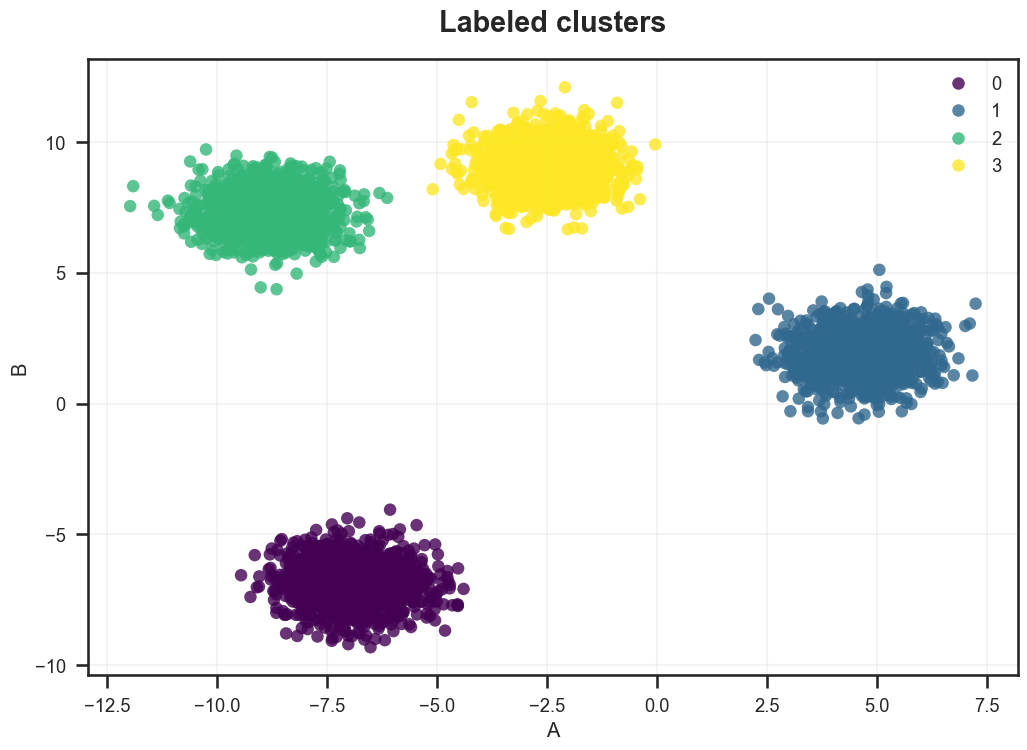

In [12]:
sns.scatterplot(data=df, x='A', y='B', hue=labels, **scatter_kwargs)
plt.title('Labeled clusters')
plt.show()

In [13]:
# Using KMeans
model = KMeans(n_clusters=4, random_state=42)
model.fit(X)

centroids = model.cluster_centers_
labels = model.labels_
inertia = model.inertia_

In [14]:
centroids

array([[ 4.62826191,  1.94726375],
       [-2.50138934,  9.05833956],
       [-6.89143046, -6.91208453],
       [-8.83866084,  7.33763741]])

In [15]:
labels

array([0, 2, 0, ..., 0, 1, 0], shape=(5000,), dtype=int32)

In [16]:
inertia

6438.463928042345

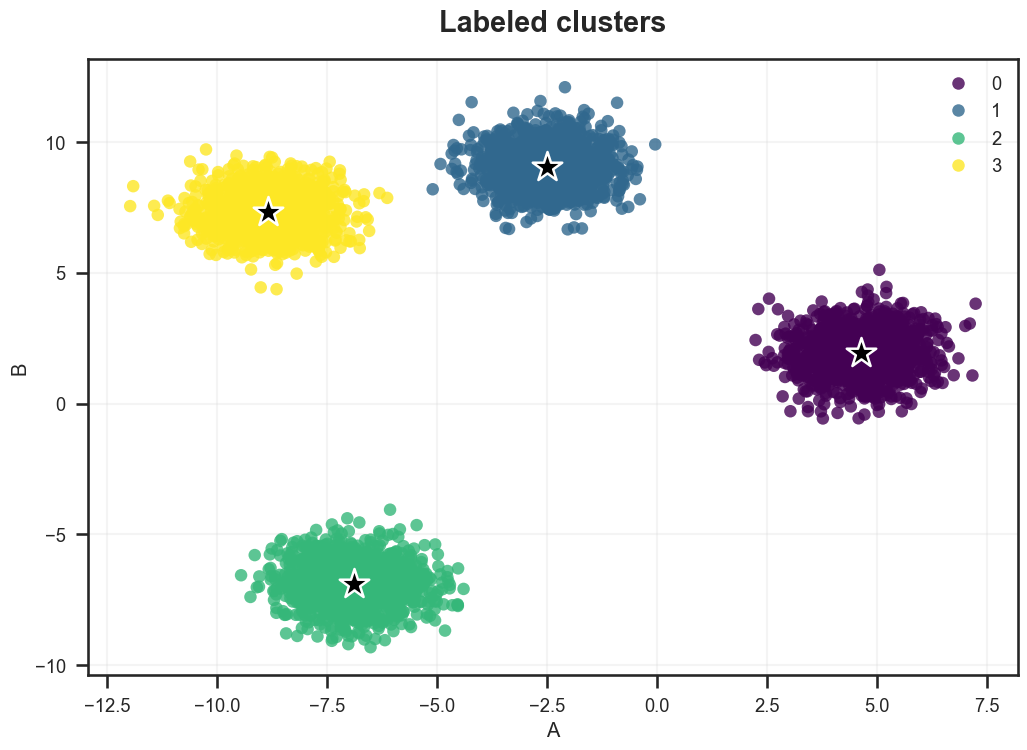

In [17]:
ax = sns.scatterplot(data=df, x='A', y='B', hue=labels, **scatter_kwargs)
sns.scatterplot(x=centroids[:,0], y=centroids[:,1], marker='*', s=500, color='black', ax=ax)

plt.title('Labeled clusters')
plt.show()

## Model evaluation

Uma boa clusterização vai produzir:
- Alta similaridade intra-cluster
- Pouca similaridade entre clusters

Métricas:
- WCSS
- Silhouette
- Davies Bouldin (`intracluster / intercluster`)
- Calinski Harabasz (`soma_intercluster / soma_intracluster`)

Exemplo de aplicação:

In [18]:
# sklearn metrics
silhouette_score(X, labels)
davies_bouldin_score(X, labels)
calinski_harabasz_score(X, labels)

84652.53492291895

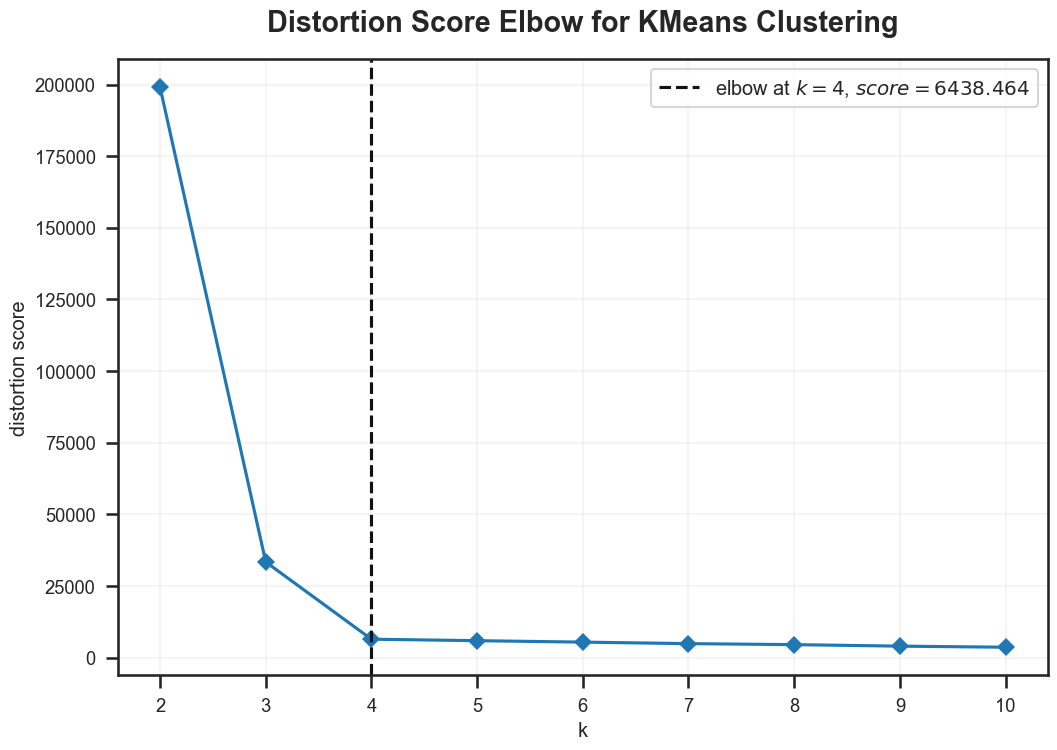

,estimator,KMeans(n_clusters=10)
,ax,<Axes: title=...ortion score'>
,k,10
,metric,'distortion'
,distance_metric,'euclidean'
,timings,False
,locate_elbow,True
,n_clusters,10
,init,'k-means++'
,n_init,'auto'
,max_iter,300


In [19]:
# kelbow_visualizer
kelbow_visualizer(KMeans(), X, k=10, timings=False)

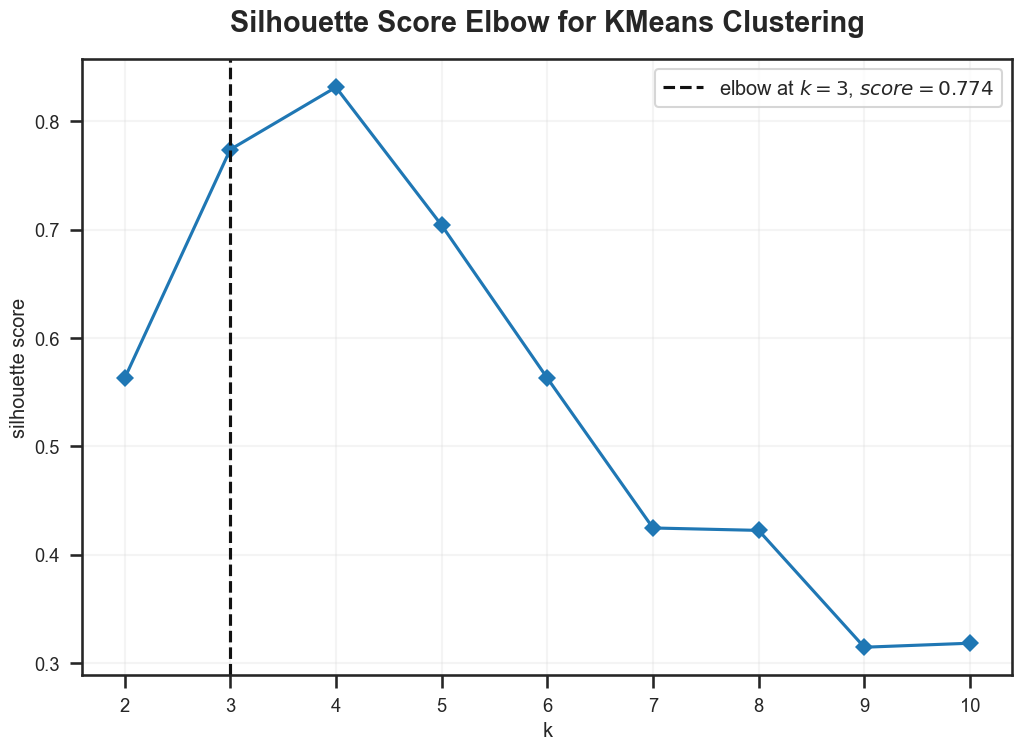

,estimator,KMeans(n_clusters=10)
,ax,<Axes: title=...ouette score'>
,k,10
,metric,'silhouette'
,distance_metric,'euclidean'
,timings,False
,locate_elbow,True
,n_clusters,10
,init,'k-means++'
,n_init,'auto'
,max_iter,300


In [20]:
# kelbow_visualizer
kelbow_visualizer(KMeans(), X, k=10, timings=False, metric='silhouette')

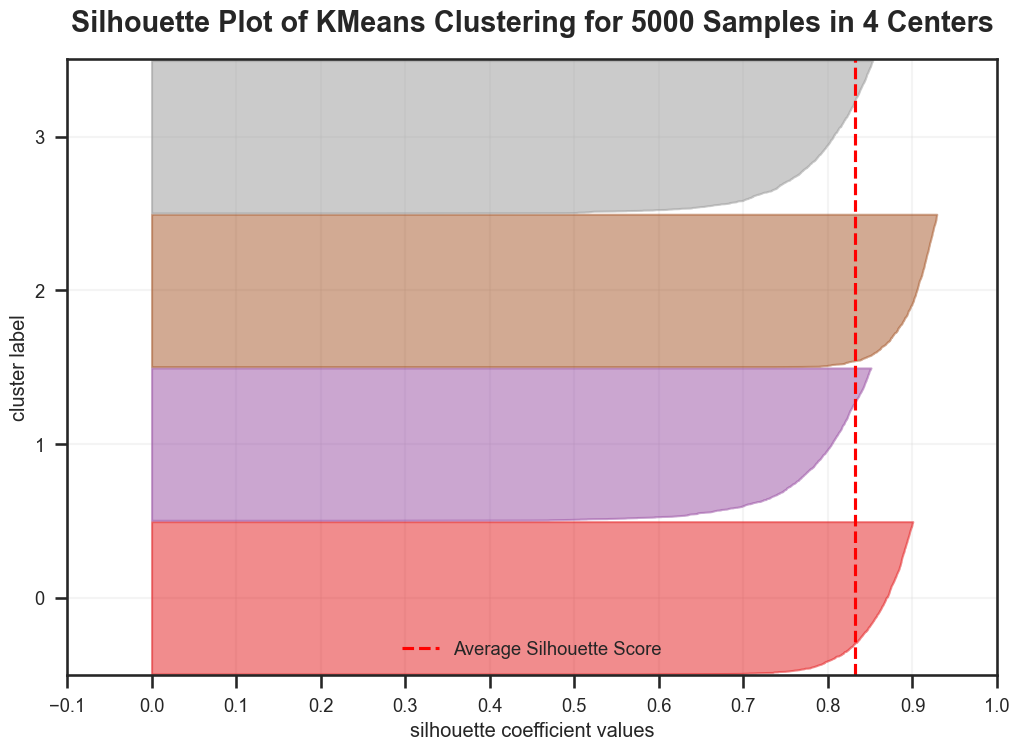

,estimator,KMeans(n_clusters=4)
,ax,<Axes: title=...luster label'>
,colors,None
,is_fitted,'auto'
,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None


In [21]:
# silhouette_visualizer
silhouette_visualizer(KMeans(n_clusters=4), X)

Testando distintos agrupamentos:

In [22]:
# Create list of dictionaries

cluster_metrics = silhouette_score, davies_bouldin_score, calinski_harabasz_score
cluster_metrics_results = []

for k in range(2,11):
  model = KMeans(n_clusters=k, random_state=0)
  labels = model.fit_predict(X)
  cluster_results_dict = {'k': k}
  cluster_results_dict['inertia'] = model.inertia_
  for metric in cluster_metrics:
    cluster_results_dict[metric.__name__] = metric(X, labels)
  cluster_metrics_results.append(cluster_results_dict)

cluster_metrics_results

[{'k': 2,
  'inertia': 165384.20786354315,
  'silhouette_score': 0.5627158249398301,
  'davies_bouldin_score': 0.9214456613549218,
  'calinski_harabasz_score': 5087.188327323066},
 {'k': 3,
  'inertia': 33389.60517411427,
  'silhouette_score': 0.7740756211383696,
  'davies_bouldin_score': 0.3399165510572917,
  'calinski_harabasz_score': 22473.30116848767},
 {'k': 4,
  'inertia': 6438.463928042344,
  'silhouette_score': 0.8316196523510032,
  'davies_bouldin_score': 0.23564938235726685,
  'calinski_harabasz_score': 84652.53492291896},
 {'k': 5,
  'inertia': 5919.370570507667,
  'silhouette_score': 0.7080051283228401,
  'davies_bouldin_score': 0.6277175906021945,
  'calinski_harabasz_score': 69157.34943268735},
 {'k': 6,
  'inertia': 5576.195729120338,
  'silhouette_score': 0.7121551277594544,
  'davies_bouldin_score': 0.5781981574067308,
  'calinski_harabasz_score': 58779.16284932036},
 {'k': 7,
  'inertia': 5058.397200751363,
  'silhouette_score': 0.5720216268358549,
  'davies_bouldin_s

In [23]:
# Create dataframe
pd.DataFrame(cluster_metrics_results).set_index('k').style.background_gradient()

,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score
k,,,,
2,165384.207864,0.562716,0.921446,5087.188327
3,33389.605174,0.774076,0.339917,22473.301168
4,6438.463928,0.831620,0.235649,84652.534923
5,5919.370571,0.708005,0.627718,69157.349433
6,5576.195729,0.712155,0.578198,58779.162849
7,5058.397201,0.572022,0.832762,54071.462166
8,4573.216787,0.445434,1.021812,51334.764198
9,4054.901376,0.308635,1.173030,50731.096659
10,3712.413946,0.313237,1.088184,49297.275734


In [24]:
# Style dataframe
(
  pd.DataFrame(cluster_metrics_results)
  .set_index('k')
  .style.background_gradient(cmap='Oranges', subset='inertia')
  .highlight_max(subset=['silhouette_score','calinski_harabasz_score'])
  .highlight_min(subset='davies_bouldin_score')
)

,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score
k,,,,
2,165384.207864,0.562716,0.921446,5087.188327
3,33389.605174,0.774076,0.339917,22473.301168
4,6438.463928,0.831620,0.235649,84652.534923
5,5919.370571,0.708005,0.627718,69157.349433
6,5576.195729,0.712155,0.578198,58779.162849
7,5058.397201,0.572022,0.832762,54071.462166
8,4573.216787,0.445434,1.021812,51334.764198
9,4054.901376,0.308635,1.173030,50731.096659
10,3712.413946,0.313237,1.088184,49297.275734


Repetindo procedimento acima com dados simulados aleatórios:

In [25]:
# X_random with numpy
X_random = np.random.rand(*X.shape)
X_random

array([[0.71386752, 0.76264817],
       [0.54839273, 0.56434678],
       [0.42003597, 0.04837771],
       ...,
       [0.69435695, 0.94234302],
       [0.64901957, 0.59848269],
       [0.64293497, 0.17894595]], shape=(5000, 2))

<Axes: >

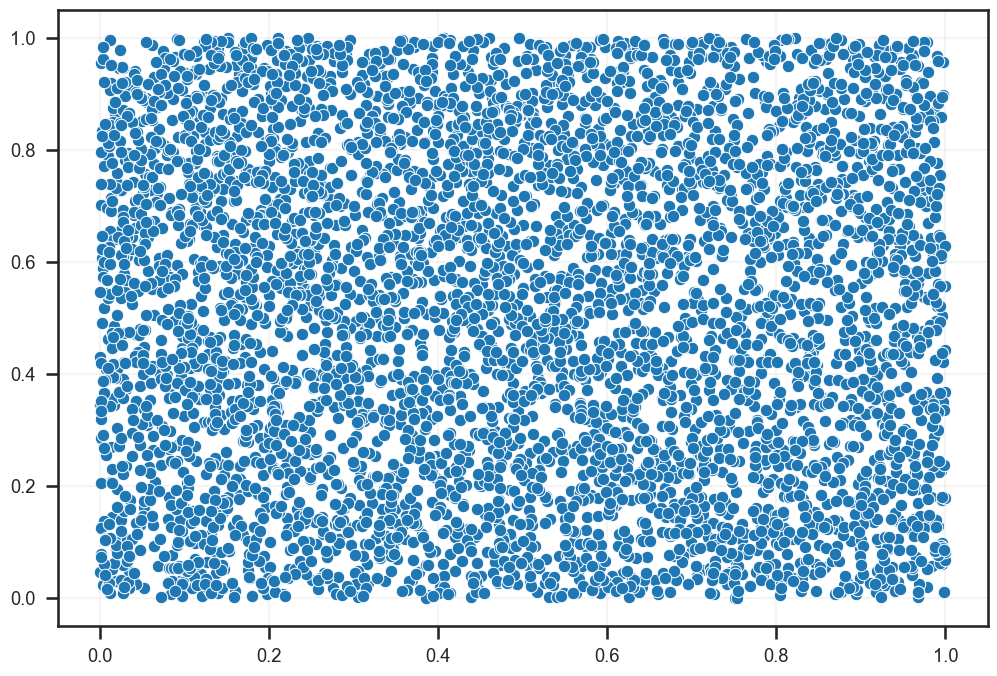

In [26]:
sns.scatterplot(x=X_random[:,0], y=X_random[:,1])

In [27]:
cluster_metrics = silhouette_score, davies_bouldin_score, calinski_harabasz_score
cluster_metrics_results = []

for k in range(2,11):
  model = KMeans(n_clusters=k, random_state=0)
  labels = model.fit_predict(X_random)
  cluster_results_dict = {'k': k}
  cluster_results_dict['inertia'] = model.inertia_
  for metric in cluster_metrics:
    cluster_results_dict[metric.__name__] = metric(X_random, labels)
  cluster_metrics_results.append(cluster_results_dict)

pd.DataFrame(cluster_metrics_results).set_index('k').style.background_gradient()

,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score
k,,,,
2,523.612961,0.361273,1.162247,3110.528976
3,340.627602,0.370753,0.874629,3732.537384
4,210.245555,0.411155,0.766180,5063.431603
5,178.120107,0.384764,0.881442,4706.854297
6,149.835780,0.379625,0.829849,4663.841473
7,128.049459,0.370594,0.806934,4688.591618
8,107.679664,0.363283,0.817651,4913.052550
9,92.130264,0.370454,0.765178,5128.582086
10,85.390938,0.357851,0.832601,4961.281376


In [28]:
# Style dataframe
(
  pd.DataFrame(cluster_metrics_results)
  .set_index('k')
  .style.background_gradient(cmap='Oranges', subset='inertia')
  .highlight_max(subset=['silhouette_score','calinski_harabasz_score'])
  .highlight_min(subset='davies_bouldin_score')
)

,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score
k,,,,
2,523.612961,0.361273,1.162247,3110.528976
3,340.627602,0.370753,0.874629,3732.537384
4,210.245555,0.411155,0.766180,5063.431603
5,178.120107,0.384764,0.881442,4706.854297
6,149.835780,0.379625,0.829849,4663.841473
7,128.049459,0.370594,0.806934,4688.591618
8,107.679664,0.363283,0.817651,4913.052550
9,92.130264,0.370454,0.765178,5128.582086
10,85.390938,0.357851,0.832601,4961.281376


Comparando de forma interativa:

In [29]:
@interact(k=(2,11), data=['X','X_random'])
def plot_kmeans(k, data):
  data = X if data=='X' else X_random
  model = KMeans(n_clusters=k, random_state=0)
  labels = model.fit_predict(data)
  sns.scatterplot(x=data[:,0], y=data[:,1], hue=labels, **scatter_kwargs)

interactive(children=(IntSlider(value=6, description='k', max=11, min=2), Dropdown(description='data', options…

## High dimensional data

In [30]:
# Simulate clusters with high dimensional data
X_dim,y_dim = datasets.make_blobs(n_samples=int(1E3), n_features=10, centers=4, cluster_std=.8, random_state=42)
df_dim = pd.DataFrame(X_dim, columns=list(string.ascii_uppercase[:X_dim.shape[1]]))
df_dim.head()

,A,B,C,D,E,F,G,H,I,J
0,-9.118025,9.893988,5.119799,-5.678834,-6.738298,-6.938922,-2.834473,-0.027815,-2.006201,-4.114861
1,-1.836683,8.492187,4.282932,0.461537,-7.241472,-8.819213,-10.105450,7.931855,2.650940,4.501818
2,-10.044176,9.661804,5.435114,-5.152754,-6.696456,-7.235965,-4.275165,1.500848,-1.789368,-3.888654
3,2.597853,-6.913228,-9.678478,8.263492,10.699874,6.475314,-3.821517,-8.246473,3.918380,-0.972761
4,1.504777,-6.902774,-7.494919,8.113709,9.442878,7.363971,-4.958099,-7.731378,3.042843,-1.600657


In [31]:
# Apply PCA
pca = PCA()
pca_components = pca.fit_transform(df_dim)

df_pca = pd.DataFrame(pca_components, columns=[f'PC{i+1}' for i in range(pca_components.shape[1])])
df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,15.073142,-4.316705,-6.739933,0.461229,-0.403220,-1.716382,0.082211,-0.994268,0.409410,-0.074076
1,14.843483,7.136611,6.223981,-2.304937,-0.067046,-0.595796,-0.847741,-0.669064,0.428498,-0.298020
2,15.839582,-3.759468,-5.679969,0.131592,0.330700,-1.194786,-0.683229,-0.312434,-0.909602,-0.470318
3,-21.142663,5.923206,-3.782550,-1.096178,-0.135291,-0.765433,0.611086,0.254755,-0.053788,-0.003252
4,-19.537622,4.767777,-3.417566,-0.032206,0.091476,1.339127,0.486056,0.829573,-0.556978,-0.906984


In [32]:
# Verify explained variance
pd.DataFrame(
    {'explained_var': pca.explained_variance_ratio_, 'explained_var_cumsum': pca.explained_variance_ratio_.cumsum()},
    index=df_pca.columns
)

,explained_var,explained_var_cumsum
PC1,0.744720,0.744720
PC2,0.157481,0.902201
PC3,0.083149,0.985350
PC4,0.002477,0.987828
PC5,0.002327,0.990154
PC6,0.002156,0.992311
PC7,0.002098,0.994408
PC8,0.001992,0.996400
PC9,0.001847,0.998247
PC10,0.001753,1.000000


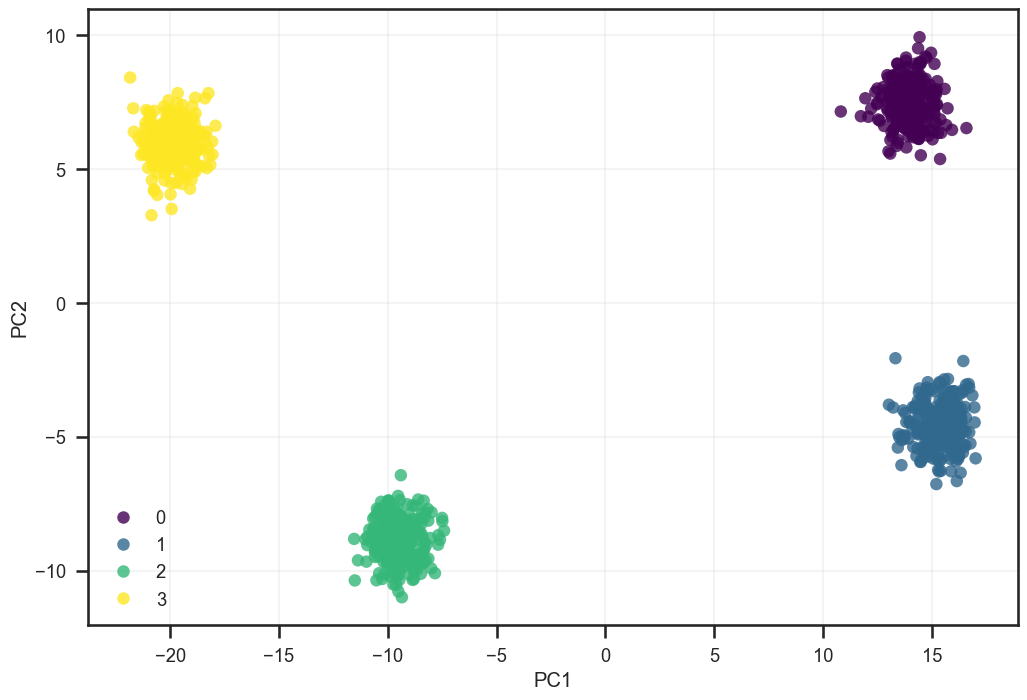

In [33]:
# Plot PCA with true label
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue=y_dim, **scatter_kwargs);

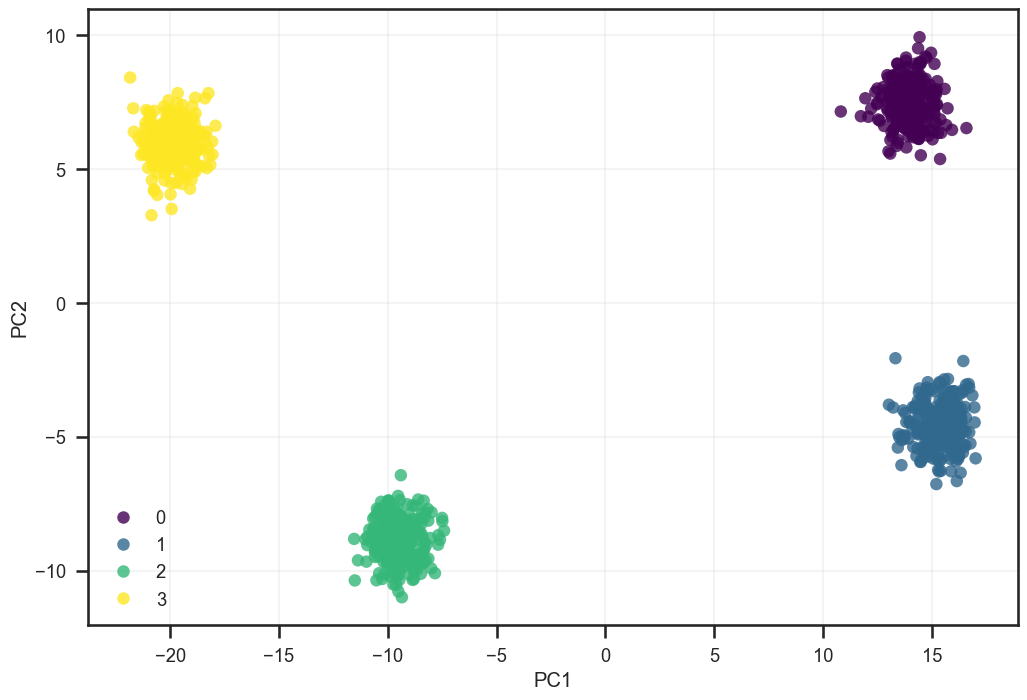

In [34]:
# Plot PCA with k-means label
labels = k_means(df_pca.iloc[:,:3], 4)[1]
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue=y_dim, **scatter_kwargs);

In [35]:
pip install --upgrade nbformat


Note: you may need to restart the kernel to use updated packages.


In [36]:
# 3D PCA plot
px.scatter_3d(df_pca, x='PC1', y='PC2', z='PC3', color=labels, template='plotly_dark')

# Hierarchical clustering

**Tipos:**
- Agglomerative (bottom-up)
- Dissimilarity (top-down)

**Vantagens:**
- Fácil interpretação
- Não é necessário estabelecer a quantidade de grupos previamente

**Desvantagens:**
- Não escala bem com muitos dados
- Dendograma fica com visualização inviável para muitas amostras

In [60]:
# Simulate clusters
X,y = datasets.make_blobs(n_samples=80, n_features=2, centers=4, cluster_std=.6, random_state=0)
df = pd.DataFrame(X, columns=list(string.ascii_uppercase[:X.shape[1]]))
df.head()

,A,B
0,-1.710205,8.159010
1,-0.397014,2.109227
2,-1.148252,8.216479
3,2.334665,-0.024083
4,-1.347961,3.713714


In [61]:
# Hierarchical clustering with sklearn
model = AgglomerativeClustering(n_clusters=4)
labels = model.fit_predict(X)

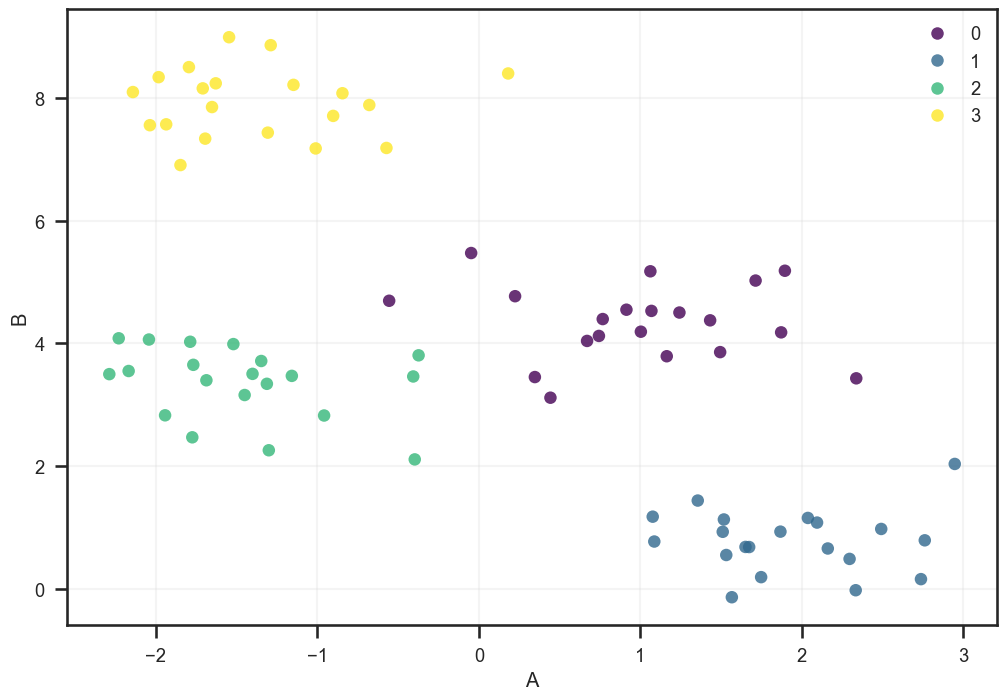

In [62]:
sns.scatterplot(data=df, x='A', y='B', hue=y, **scatter_kwargs);

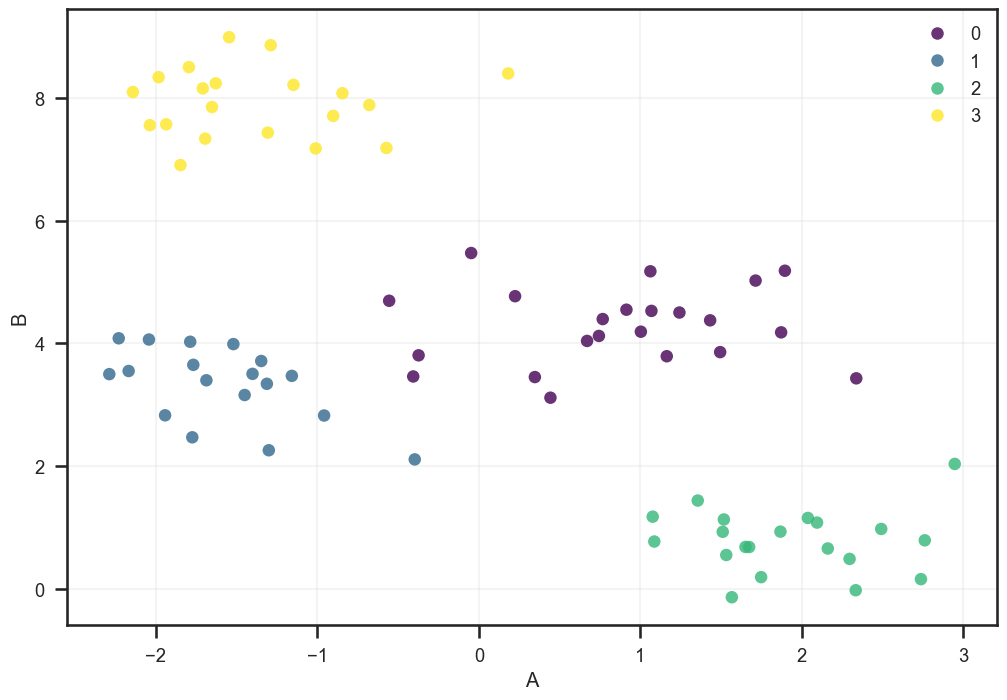

In [63]:
sns.scatterplot(data=df, x='A', y='B', hue=labels, **scatter_kwargs);

## Hierarchical clustering with scipy

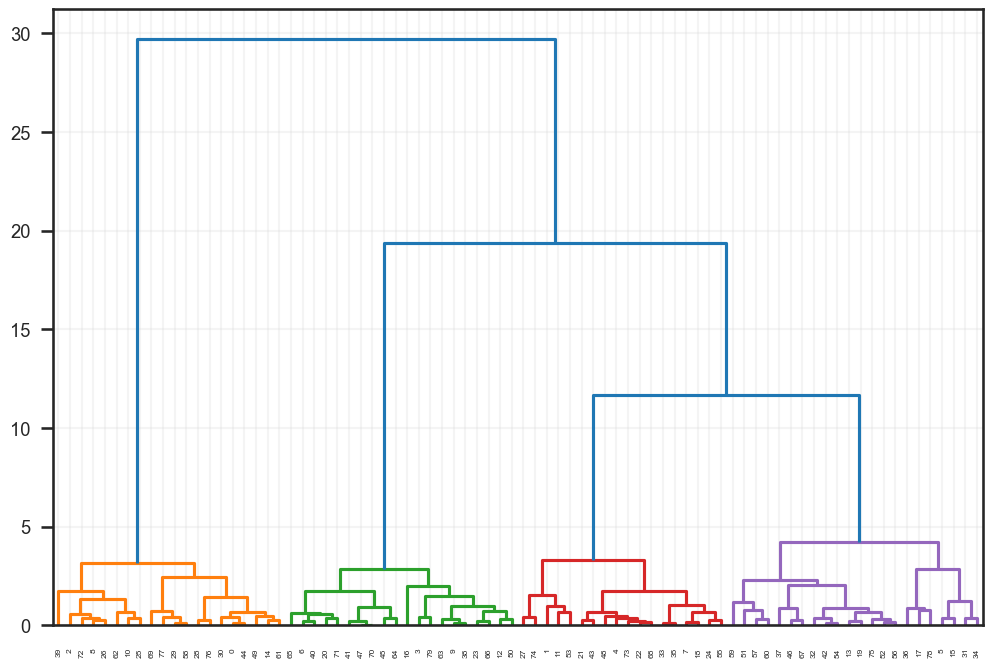

In [70]:
Z = linkage(df, method='ward')
dendrogram_dict = dendrogram(Z, color_threshold=10)
plt.show()

In [87]:
fcluster(Z, 4, criterion='maxclust')

array([1, 3, 1, 2, 3, 4, 2, 3, 1, 2, 1, 3, 2, 4, 1, 4, 2, 4, 3, 4, 2, 3,
       3, 2, 3, 1, 1, 3, 1, 1, 1, 4, 4, 3, 4, 3, 4, 4, 2, 1, 2, 2, 4, 3,
       1, 2, 4, 2, 3, 1, 2, 4, 4, 3, 4, 3, 4, 4, 1, 4, 4, 1, 1, 2, 2, 2,
       2, 4, 3, 1, 2, 2, 1, 3, 3, 4, 1, 1, 4, 2], dtype=int32)

In [88]:
@interact(method=['single','complete','centroid', 'ward'])
def plot_dendrogram(method):
  Z = linkage(df, method=method)
  dendrogram_dict = dendrogram(Z)
  plt.show()

interactive(children=(Dropdown(description='method', options=('single', 'complete', 'centroid', 'ward'), value…

# DBSCAN

**Vantagens:**
- Não necessita especificar a quantidade de clusters
- Detecta clusters de formatos variados (densos)
- Robusto aos outliers

**Desvantagens:**
- A qualidade do cluster depende muito métrica de distância
- Não funciona bem em clusters com densidades diferentes (OPTICS)

In [89]:
# Simulate clusters
X,y = datasets.make_blobs(n_samples=int(5E3), n_features=2, centers=4, cluster_std=.8, random_state=0)
df = pd.DataFrame(X, columns=list(string.ascii_uppercase[:X.shape[1]]))
df.head()

,A,B
0,1.998996,1.535900
1,-2.788784,2.773154
2,-0.956255,3.630438
3,2.777738,-1.508286
4,0.982364,5.013279


In [90]:
# Train DBSCAN
model = DBSCAN()
labels = model.fit_predict(X)

In [91]:
# Train DBSCAN (function)
labels = dbscan(X)[1]

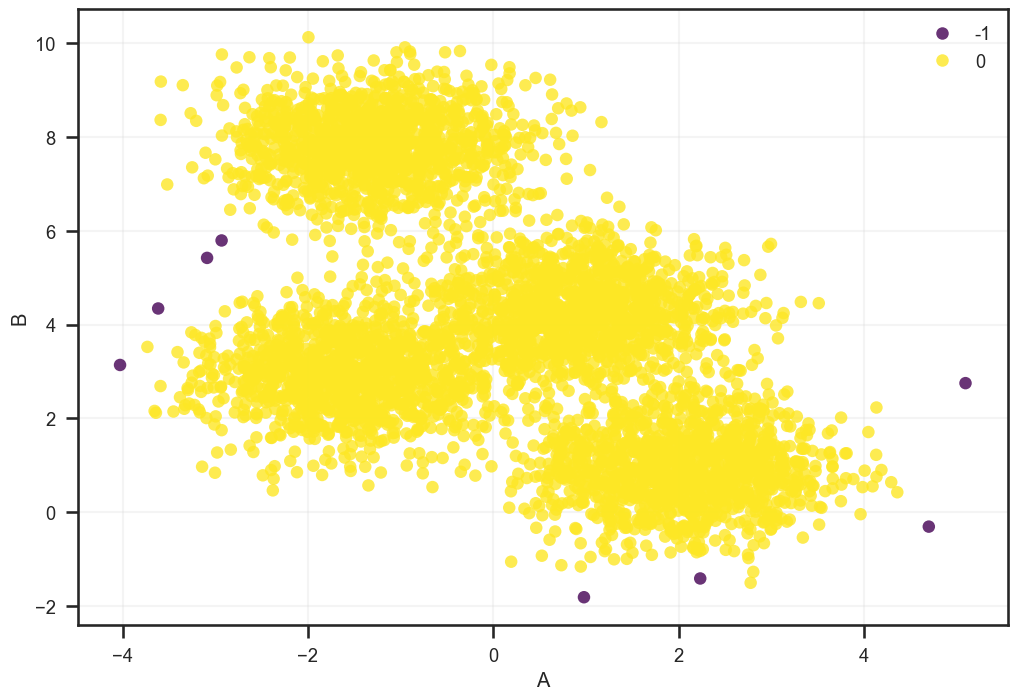

In [92]:
# Visualize output
sns.scatterplot(data=df, x='A', y='B', hue=labels, **scatter_kwargs);

In [93]:
@interact(eps=(0.01,1, 0.01), min_samples=(1,20))
def custom_dbscan(eps, min_samples):
  _, labels = dbscan(X, eps=eps, min_samples=min_samples)
  sns.scatterplot(data=df, x='A', y='B', hue=labels, palette='tab10')
  plt.show()

interactive(children=(FloatSlider(value=0.5, description='eps', max=1.0, min=0.01, step=0.01), IntSlider(value…

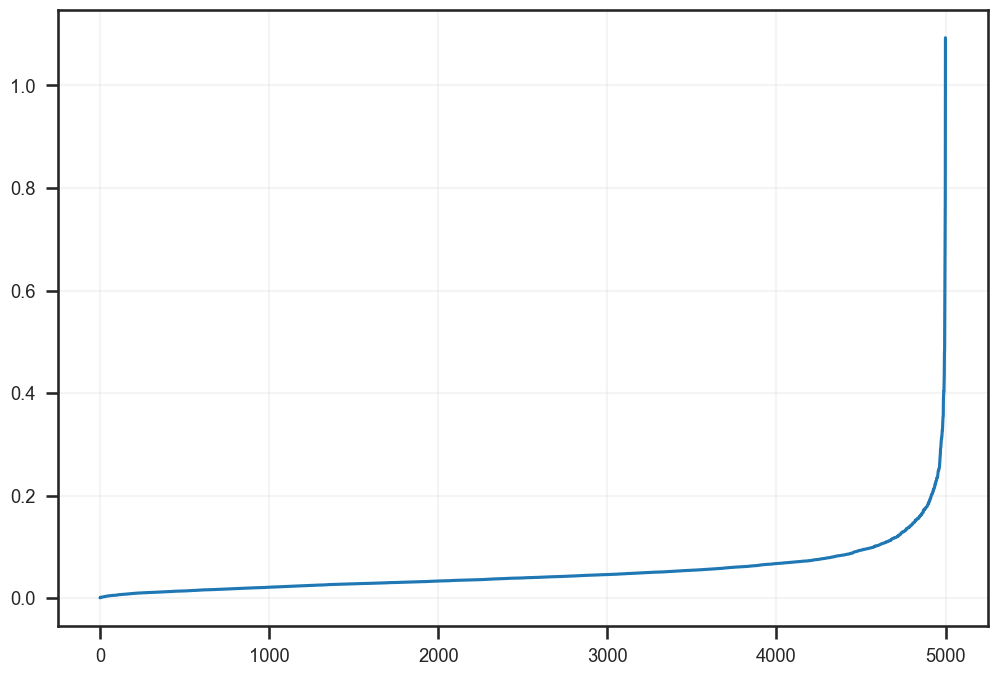

In [95]:
# https://towardsdatascience.com/machine-learning-clustering-dbscan-determine-the-optimal-value-for-epsilon-eps-python-example-3100091cfbc
from sklearn.neighbors import NearestNeighbors
nn_model = NearestNeighbors(n_neighbors=2).fit(X)
distances, indices = nn_model.kneighbors(X)
distances = np.sort(distances, axis=0)
plt.plot(distances[:,1])
plt.show()